# 📊 Retail Transactions Dataset - Data Dictionary

## 📁 Columns Description

| Column Name        | Data Type        | Description                                                   | Example                |
|-------------------|------------------|---------------------------------------------------------------|------------------------|
| transaction_id    | String           | Unique identifier for each transaction                        | TXN-106332             |
| customer_id       | String           | Unique identifier for each customer                           | CUST-2428              |
| transaction_date  | Date             | Date when the transaction occurred                            | 2022-10-21             |
| category          | Categorical      | Product category                                              | Automotive             |
| item              | String           | Name of the purchased item                                    | Steering Wheel Cover   |
| quantity          | Integer          | Number of items purchased                                     | 1                      |
| unit_price        | Float            | Price per single unit                                         | 23.14                  |
| discount          | Float            | Discount applied (percentage or fraction)                     | 0.25                   |
| total_spent       | Float            | Final amount paid after discount                              | 17.36                  |
| payment_method    | Categorical      | Method of payment                                             | Cash                   |
| location          | Categorical      | Platform/channel of purchase                                  | Online / Mobile App    |
| region            | Categorical      | Geographic region of the transaction                          | East                   |
| customer_segment  | Categorical      | Customer classification (e.g., VIP, Premium)                  | VIP                    |
| rating            | Float            | Customer rating for the purchase (e.g., 1–5 scale)            | 1.6                    |
| returned          | Boolean / Float  | Indicates if item was returned (1 = Yes, 0 = No)              | 0                      |

---

## 📌 Notes

- **total_spent = quantity × unit_price × (1 - discount)**
- `discount` is stored as a fraction (e.g., 0.25 = 25%)
- `returned`:
  - `1` → Returned
  - `0` → Not returned
- Some columns may contain missing values:
  - `location`
  - `customer_segment`

---

## 📈 Suggested Analysis

- Sales by **category / region**
- Impact of **discount on total_spent**
- Customer behavior by **segment**
- Return rate analysis
- Rating vs purchase patterns

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

In [2]:
df=pd.read_csv("retail_store_sales.csv")
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1,23.14,0.25,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-102903,CUST-1858,2022-01-23,Home & Kitchen,Coffee Maker,10,66.93,0.17,555.52,Cash,NaN,East,Premium,3.6,0.0
2,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,NaN,2.5,0.0
3,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
4,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5,72.73,0.09,330.92,PayPal,Online,West,VIP,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10145,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9,20.3,0.21,144.33,Cash,Mobile App,West,NaN,4.4,0.0
10146,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4,41.03,0.11,146.07,Credit Card,Mobile App,East,New,5.0,0.0
10147,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2,22.31,0.24,33.91,Cash,Mobile App,South,Premium,2.7,0.0
10148,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3,21.45,0.24,48.91,PayPal,Online,West,New,2.6,0.0


In [3]:
df[df["returned"]==1]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
3,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
5,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9,18.38,NaN,147.22,Cash,Online,North,Regular,1.5,1.0
8,TXN-102648,CUST-3161,2022-05-05,Electronics,Mechanical Keyboard,4,109.11,0.15,370.97,Bank Transfer,Mobile App,NaN,New,NaN,1.0
14,TXN-108698,CUST-4239,2023-07-22,Clothing,Winter Jacket,8,134.06,0.25,804.36,Cash,Mobile App,West,Regular,3.3,1.0
18,TXN-106120,CUST-4773,11-05-2023,Electronics,Tablet,1,$345.9,0.02,338.98,Bank Transfer,Online,Central,Regular,3.8,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10127,TXN-106191,CUST-1259,2024-09-19,Books,ERROR,10,52.46,0.15,445.91,Credit Card,Online,East,New,3.0,1.0
10130,TXN-101044,CUST-2750,2024-04-21,Beauty & Personal Care,Shampoo Set,1,25.51,0.04,24.49,PayPal,Online,North,Regular,4.7,1.0
10135,TXN-109579,CUST-1791,2022-06-25,Home & Kitchen,Blender,9,54.37,0.04,469.76,Credit Card,Online,NaN,VIP,1.5,1.0
10138,TXN-108368,CUST-1422,2022-03-19,Automotive,Car Air Freshener,7,10.38,0.03,70.48,PayPal,Mobile App,South,NaN,1.1,1.0


In [4]:
num_col=df.select_dtypes(include="number").columns
num_col

Index(['discount', 'total_spent', 'rating', 'returned'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10150 non-null  str    
 1   customer_id       10150 non-null  str    
 2   transaction_date  10150 non-null  str    
 3   category          10150 non-null  str    
 4   item              10127 non-null  str    
 5   quantity          10061 non-null  str    
 6   unit_price        10150 non-null  str    
 7   discount          9692 non-null   float64
 8   total_spent       10150 non-null  float64
 9   payment_method    9920 non-null   str    
 10  location          9949 non-null   str    
 11  region            9764 non-null   str    
 12  customer_segment  9804 non-null   str    
 13  rating            9625 non-null   float64
 14  returned          9853 non-null   float64
dtypes: float64(4), str(11)
memory usage: 2.0 MB


In [6]:
df.describe()

,discount,total_spent,rating,returned
count,9692.000000,10150.000000,9625.000000,9853.000000
mean,0.150203,395.794342,3.067626,0.204405
std,0.086771,752.169698,3.001788,0.403286
min,0.000000,-2716.450000,0.000000,0.000000
25%,0.070000,92.955000,2.000000,0.000000
50%,0.150000,193.705000,3.000000,0.000000
75%,0.230000,381.515000,4.000000,0.000000
max,0.300000,9583.020000,99.000000,1.000000


In [7]:
(df.isna().sum() / df.shape[0]) * 100

transaction_id      0.000000
customer_id         0.000000
transaction_date    0.000000
category            0.000000
item                0.226601
quantity            0.876847
unit_price          0.000000
discount            4.512315
total_spent         0.000000
payment_method      2.266010
location            1.980296
region              3.802956
customer_segment    3.408867
rating              5.172414
returned            2.926108
dtype: float64

In [8]:
df.isna().any(axis=1).mean() * 100

np.float64(22.453201970443352)

In [9]:
df.head()

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1,23.14,0.25,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-102903,CUST-1858,2022-01-23,Home & Kitchen,Coffee Maker,10,66.93,0.17,555.52,Cash,NaN,East,Premium,3.6,0.0
2,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,NaN,2.5,0.0
3,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
4,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5,72.73,0.09,330.92,PayPal,Online,West,VIP,2.0,0.0


In [10]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.23
quantity            0.88
unit_price          0.00
discount            4.51
total_spent         0.00
payment_method      2.27
location            1.98
region              3.80
customer_segment    3.41
rating              5.17
returned            2.93
dtype: float64

## Drop these row that contain <3%

In [11]:
df.dropna(subset=["item","quantity","payment_method","location"],inplace=True,ignore_index=True)

In [12]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1,23.14,0.25,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,NaN,2.5,0.0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5,72.73,0.09,330.92,PayPal,Online,West,VIP,2.0,0.0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9,18.38,NaN,147.22,Cash,Online,North,Regular,1.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9618,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9,20.3,0.21,144.33,Cash,Mobile App,West,NaN,4.4,0.0
9619,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4,41.03,0.11,146.07,Credit Card,Mobile App,East,New,5.0,0.0
9620,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2,22.31,0.24,33.91,Cash,Mobile App,South,Premium,2.7,0.0
9621,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3,21.45,0.24,48.91,PayPal,Online,West,New,2.6,0.0


In [13]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              3.82
customer_segment    3.46
rating              5.14
returned            2.89
dtype: float64

In [14]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              3.82
customer_segment    3.46
rating              5.14
returned            2.89
dtype: float64

In [15]:
df.describe(include="object")

C:\Users\hooda\AppData\Local\Temp\ipykernel_13024\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,payment_method,location,region,customer_segment
count,9623,9623,9623,9623,9623,9623,9623,9623,9623,9255,9290
unique,9478,3607,1517,8,82,35,6411,7,5,5,6
top,TXN-102441,CUST-2002,2023-01-09,Sports & Outdoors,Drone Mini,1,34.87,PayPal,Online,North,New
freq,2,9,20,1228,143,979,8,1980,3224,1934,2446


In [16]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              3.82
customer_segment    3.46
rating              5.14
returned            2.89
dtype: float64

In [17]:
cat=df.select_dtypes(include="str").columns.drop(["customer_id","transaction_id"])
cat
for i in cat:
    px.histogram(data_frame=df,x=i,title=i).show()  

In [18]:
df["region"]=df["region"].fillna("North",inplace=True)

C:\Users\hooda\AppData\Local\Temp\ipykernel_13024\1087715791.py:1: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html



In [19]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              0.00
customer_segment    3.46
rating              5.14
returned            2.89
dtype: float64

In [20]:
df["region"].isna().sum()

np.int64(0)

In [21]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              0.00
customer_segment    3.46
rating              5.14
returned            2.89
dtype: float64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9623 entries, 0 to 9622
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    9623 non-null   str    
 1   customer_id       9623 non-null   str    
 2   transaction_date  9623 non-null   str    
 3   category          9623 non-null   str    
 4   item              9623 non-null   str    
 5   quantity          9623 non-null   str    
 6   unit_price        9623 non-null   str    
 7   discount          9190 non-null   float64
 8   total_spent       9623 non-null   float64
 9   payment_method    9623 non-null   str    
 10  location          9623 non-null   str    
 11  region            9623 non-null   str    
 12  customer_segment  9290 non-null   str    
 13  rating            9128 non-null   float64
 14  returned          9345 non-null   float64
dtypes: float64(4), str(11)
memory usage: 1.9 MB


In [23]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              0.00
customer_segment    3.46
rating              5.14
returned            2.89
dtype: float64

In [24]:
px.histogram(data_frame=df,x="region")

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9623 entries, 0 to 9622
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    9623 non-null   str    
 1   customer_id       9623 non-null   str    
 2   transaction_date  9623 non-null   str    
 3   category          9623 non-null   str    
 4   item              9623 non-null   str    
 5   quantity          9623 non-null   str    
 6   unit_price        9623 non-null   str    
 7   discount          9190 non-null   float64
 8   total_spent       9623 non-null   float64
 9   payment_method    9623 non-null   str    
 10  location          9623 non-null   str    
 11  region            9623 non-null   str    
 12  customer_segment  9290 non-null   str    
 13  rating            9128 non-null   float64
 14  returned          9345 non-null   float64
dtypes: float64(4), str(11)
memory usage: 1.9 MB


In [26]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              0.00
customer_segment    3.46
rating              5.14
returned            2.89
dtype: float64

In [27]:
df[df["customer_segment"].isna()]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,NaN,2.5,0.0
61,TXN-106896,CUST-2052,2023-08-24,Home & Kitchen,Cookware Set,9,142.67,0.04,1232.67,Cash,Mobile App,North,NaN,1.5,0.0
80,TXN-105769,CUST-4007,2022-07-21,Books,The Pragmatic Programmer,9,43.64,NaN,353.48,Bank Transfer,Mobile App,North,NaN,4.7,0.0
128,TXN-105344,CUST-3795,2023-12-07,Sports & Outdoors,Protein Powder,4,54.06,NaN,201.10,PayPal,In-Store,Central,NaN,1.3,0.0
166,TXN-103000,CUST-2179,2022-11-15,Sports & Outdoors,Water Bottle,6,23.55,0.01,139.89,Cash,Mobile App,South,NaN,1.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9540,TXN-105864,CUST-1576,2023-05-01,Sports & Outdoors,Treadmill,5,597.9,0.10,2690.55,Credit Card,In-Store,Central,NaN,4.6,1.0
9544,TXN-107544,CUST-1770,2023-03-30,Beauty & Personal Care,Shampoo Set,5,23.04,0.23,88.70,Cash,Online,Central,NaN,2.3,1.0
9607,TXN-108436,CUST-3382,2022-10-13,Automotive,Jump Starter,10,83.46,0.29,592.57,Cash,In-Store,East,NaN,1.3,0.0
9611,TXN-108368,CUST-1422,2022-03-19,Automotive,Car Air Freshener,7,10.38,0.03,70.48,PayPal,Mobile App,South,NaN,1.1,1.0


In [28]:
px.histogram(data_frame=df,x="customer_segment")

In [29]:
df["customer_segment"]=df["customer_segment"].fillna("ERROR",inplace=True)

C:\Users\hooda\AppData\Local\Temp\ipykernel_13024\965576734.py:1: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html



In [30]:
px.histogram(data_frame=df,x="customer_segment")

In [31]:
df["item"].value_counts()

item
Drone Mini                 143
Car Phone Mount            143
Business Analytics         141
Python for Data Science    137
Kitchen Knife Set          136
                          ... 
Tire Inflator               97
Lego Creator Set            97
Statistics 101              88
UNKNOWN                     30
ERROR                       26
Name: count, Length: 82, dtype: int64

In [32]:
px.pie(data_frame=df,names="category")

In [33]:
df.isna().mean().round(4) * 100 

transaction_id      0.00
customer_id         0.00
transaction_date    0.00
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              0.00
customer_segment    0.00
rating              5.14
returned            2.89
dtype: float64

In [34]:
df.describe(include="str")

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,payment_method,location,region,customer_segment
count,9623,9623,9623,9623,9623,9623,9623,9623,9623,9623,9623
unique,9478,3607,1517,8,82,35,6411,7,5,5,6
top,TXN-102441,CUST-2002,2023-01-09,Sports & Outdoors,Drone Mini,1,34.87,PayPal,Online,North,New
freq,2,9,20,1228,143,979,8,1980,3224,2302,2446


In [35]:
cat=df.select_dtypes(include= 'str').columns
cat

Index(['transaction_id', 'customer_id', 'transaction_date', 'category', 'item',
       'quantity', 'unit_price', 'payment_method', 'location', 'region',
       'customer_segment'],
      dtype='str')

In [36]:
print(df["quantity"].unique())

<ArrowStringArray>
[       '1',        '7',        '2',        '5',        '9',        '4',
       '10',        '8',  '8 units',        '3',        '6',  '9 units',
  'UNKNOWN',     '2pcs',       '-5',    '10pcs',  '1 units',     '4pcs',
  '7 units',       '-3',     '8pcs',     '6pcs',       '-4',       '-2',
     '7pcs', '10 units',  '2 units',  '3 units',  '4 units',     '9pcs',
     '3pcs',  '6 units',     '1pcs',     '5pcs',  '5 units']
Length: 35, dtype: str


In [37]:
for x in cat:
    print(x)
    print(df[x].nunique())
    print(df[x].unique())  
    print("--------------------------------------------------")  

transaction_id
9478
<ArrowStringArray>
['TXN-106332', 'TXN-105698', 'TXN-100808', 'TXN-100488', 'TXN-105353',
 'TXN-108672', 'TXN-102648', 'TXN-107231', 'TXN-102479', 'TXN-104058',
 ...
 'TXN-100055', 'TXN-107971', 'TXN-103457', 'TXN-107365', 'TXN-105188',
 'TXN-107890', 'TXN-101768', 'TXN-109929', 'TXN-103240', 'TXN-107203']
Length: 9478, dtype: str
--------------------------------------------------
customer_id
3607
<ArrowStringArray>
['CUST-2428', 'CUST-3147', 'CUST-4622', 'CUST-3616', 'CUST-1082', 'CUST-2934',
 'CUST-3161', 'CUST-3883', 'CUST-3363', 'CUST-1705',
 ...
 'CUST-4360', 'CUST-3930', 'CUST-1745', 'CUST-4220', 'CUST-3518', 'CUST-3787',
 'CUST-1400', 'CUST-4415', 'CUST-4023', 'CUST-2134']
Length: 3607, dtype: str
--------------------------------------------------
transaction_date
1517
<ArrowStringArray>
['2022-10-21', '2024-06-16', '2023-04-20', '2022-06-05', '2023-06-12',
 '2024-03-18', '2022-05-05', '2024-06-17', '2023-12-31', '2023-12-18',
 ...
 '29/06/2022', '25-10-2022'

## cleaned the column of date

In [38]:
"x/y/z".split("/")



['x', 'y', 'z']

In [39]:
temp="11-05-2023".split("-")
temp[0],temp[2]=temp[2],temp[0]
temp
result="-".join(temp)
result

'2023-05-11'

In [40]:
def clean_date(x):
    if x[2]=="-" : 
        temp=x.split("-")
        temp[0],temp[2]=temp[2],temp[0]
        result="-".join(temp)
        return result
    elif x[2]=="/":
        temp=x.split("/")
        temp[0],temp[2]=temp[2],temp[0]
        result="-".join(temp)
    else:
        return x    
    

In [41]:
df["transaction_date"]=df["transaction_date"].apply(clean_date)

In [42]:
df["transaction_date"]=pd.to_datetime(df["transaction_date"])

## Handle Unkown rows 

In [43]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1,23.14,0.25,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,ERROR,2.5,0.0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5,72.73,0.09,330.92,PayPal,Online,West,VIP,2.0,0.0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9,18.38,NaN,147.22,Cash,Online,North,Regular,1.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9618,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9,20.3,0.21,144.33,Cash,Mobile App,West,ERROR,4.4,0.0
9619,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4,41.03,0.11,146.07,Credit Card,Mobile App,East,New,5.0,0.0
9620,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2,22.31,0.24,33.91,Cash,Mobile App,South,Premium,2.7,0.0
9621,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3,21.45,0.24,48.91,PayPal,Online,West,New,2.6,0.0


In [44]:
df["item"].value_counts()

item
Drone Mini                 143
Car Phone Mount            143
Business Analytics         141
Python for Data Science    137
Kitchen Knife Set          136
                          ... 
Tire Inflator               97
Lego Creator Set            97
Statistics 101              88
UNKNOWN                     30
ERROR                       26
Name: count, Length: 82, dtype: int64

## Fill UNKNOWN rows in item with mode of every category

In [45]:
def handle_unkown_payment_method(x):
    if x == "UNKNOWN":       
        return "PayPal"
    else:
        return x
def handle_unkown_location(x):
    if x == "UNKNOWN":       
        return "Online"
    else:
        return x  
def handle_unit_customer_segment(x):
    if x == "UNKNOWN":       
        return "New"
    else:
        return x         

In [46]:
df["payment_method"]=df["payment_method"].apply(handle_unkown_payment_method)
df["location"]=df["location"].apply(handle_unkown_location)
df["customer_segment"]=df["customer_segment"].apply(handle_unit_customer_segment)

In [47]:
df[df["item"]=="Car Phone Mount"]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
76,TXN-102608,CUST-1046,2022-06-24,Automotive,Car Phone Mount,2,21.96,0.27,32.06,Cash,Mobile App,Central,Regular,3.5,1.0
117,TXN-104955,CUST-1782,2024-03-11,Automotive,Car Phone Mount,6,18.67,0.10,100.82,Debit Card,Mobile App,Central,Regular,4.6,0.0
129,TXN-104551,CUST-1732,2022-10-14,Automotive,Car Phone Mount,1,20.74,0.01,20.53,Cash,In-Store,East,Premium,1.5,0.0
146,TXN-106899,CUST-1049,2024-12-18,Automotive,Car Phone Mount,5,19.42,0.24,73.80,Credit Card,Online,West,Premium,4.5,0.0
228,TXN-106668,CUST-1976,2022-01-06,Automotive,Car Phone Mount,4,18.83,0.09,68.54,Credit Card,In-Store,North,VIP,2.4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9235,TXN-105436,CUST-3771,2023-11-06,Automotive,Car Phone Mount,1,20.92,0.24,15.90,Credit Card,Mobile App,South,VIP,1.8,0.0
9238,TXN-106974,CUST-4921,2022-03-19,Automotive,Car Phone Mount,10,20.95,0.14,180.17,Debit Card,Mobile App,South,Premium,1.4,0.0
9313,TXN-101849,CUST-1706,2023-01-22,Automotive,Car Phone Mount,8,21.98,0.19,142.43,Debit Card,Mobile App,South,Regular,4.5,0.0
9480,TXN-109720,CUST-4966,2024-10-11,Automotive,Car Phone Mount,4,20.76,0.25,62.28,Cash,In-Store,East,Premium,1.6,0.0


In [48]:
df[df["item"]=="Drone Mini"]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
21,TXN-106942,CUST-2129,2023-10-21,Toys & Games,Drone Mini,1,84.31,0.15,71.66,Debit Card,In-Store,West,VIP,4.9,1.0
30,TXN-101066,CUST-1482,2024-06-19,Toys & Games,Drone Mini,8,98.86,0.19,640.61,Debit Card,Mobile App,Central,VIP,2.3,0.0
162,TXN-105098,CUST-3992,2022-10-24,Toys & Games,Drone Mini,8,84.25,0.02,660.52,Debit Card,In-Store,North,Premium,2.7,0.0
219,TXN-102188,CUST-2114,2022-04-08,Toys & Games,Drone Mini,1,94.69,0.07,88.06,Credit Card,Mobile App,South,VIP,2.6,0.0
251,TXN-108366,CUST-4553,2024-04-03,Toys & Games,Drone Mini,3,96.01,0.05,273.63,PayPal,In-Store,South,Premium,1.9,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9288,TXN-106751,CUST-2234,2022-06-19,Toys & Games,Drone Mini,1,92.99,0.05,88.34,Bank Transfer,In-Store,Central,Regular,4.2,1.0
9369,TXN-109498,CUST-3595,2022-06-20,Toys & Games,Drone Mini,6,92.81,0.03,540.15,PayPal,In-Store,North,Regular,1.7,1.0
9412,TXN-107075,CUST-3451,2023-06-29,Toys & Games,Drone Mini,7,98.87,0.08,636.72,Debit Card,Online,West,New,3.0,1.0
9536,TXN-100740,CUST-4177,2024-02-08,Toys & Games,Drone Mini,10 units,86.44,0.29,613.72,Credit Card,Online,West,VIP,3.5,0.0


In [49]:
df[df["item"]=="UNKNOWN"]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
898,TXN-105711,CUST-2641,2022-02-17,Toys & Games,UNKNOWN,2,32.93,0.07,61.25,PayPal,Online,North,Premium,3.5,0.0
1321,TXN-101280,CUST-1307,2024-01-16,Beauty & Personal Care,UNKNOWN,2,21.39,NaN,30.37,PayPal,Online,East,New,1.1,0.0
1366,TXN-102251,CUST-1708,2024-05-26,Clothing,UNKNOWN,6,33.6,0.14,173.38,PayPal,In-Store,West,Premium,4.8,0.0
1624,TXN-108832,CUST-3081,2024-07-23,Books,UNKNOWN,3,27.44,0.22,64.21,Debit Card,In-Store,South,VIP,3.4,0.0
1732,TXN-106724,CUST-4029,2023-04-25,Toys & Games,UNKNOWN,5,53.34,0.18,218.69,PayPal,In-Store,Central,VIP,4.2,0.0
2202,TXN-108888,CUST-2436,2024-11-10,Automotive,UNKNOWN,9,80.32,0.10,650.59,Credit Card,In-Store,West,Premium,2.7,0.0
2528,TXN-107200,CUST-2085,2023-12-06,Clothing,UNKNOWN,8,80.45,0.21,508.44,Credit Card,In-Store,Central,VIP,4.0,0.0
2549,TXN-100489,CUST-4914,2023-06-13,Beauty & Personal Care,UNKNOWN,6,29.29,0.30,123.02,Debit Card,In-Store,North,Regular,3.0,0.0
3189,TXN-109414,CUST-4894,2022-07-08,Home & Kitchen,UNKNOWN,1,90.79,0.25,68.09,Bank Transfer,Online,North,Premium,4.1,0.0
3600,TXN-108316,CUST-3889,2023-01-06,Automotive,UNKNOWN,2,25.27,0.28,36.39,Bank Transfer,Online,West,VIP,NaN,0.0


#### Fill the unkown item according to mode of each category of this item 

In [50]:
def handle_unkown_item(x):
    if x["item"] == "UNKNOWN":       
        if x["category"] == "Toys & Games":
            return "Drone Mini"
        elif x["category"] == "Books":
            return "The Pragmatic Programmer"
        elif x["category"] == "Home & Kitchen":
            return "Kitchen Knife Set"
        elif x["category"] == "Clothing":
            return "Cotton T-Shirt"
        elif x["category"] == "Automotive":
            return "Car Phone Mount"
    return x["item"]

In [51]:
df["item"] = df.apply(handle_unkown_item, axis=1)

In [52]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1,23.14,0.25,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,ERROR,2.5,0.0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5,72.73,0.09,330.92,PayPal,Online,West,VIP,2.0,0.0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9,18.38,NaN,147.22,Cash,Online,North,Regular,1.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9618,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9,20.3,0.21,144.33,Cash,Mobile App,West,ERROR,4.4,0.0
9619,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4,41.03,0.11,146.07,Credit Card,Mobile App,East,New,5.0,0.0
9620,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2,22.31,0.24,33.91,Cash,Mobile App,South,Premium,2.7,0.0
9621,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3,21.45,0.24,48.91,PayPal,Online,West,New,2.6,0.0


In [53]:
df.isna().mean().round(4) * 100

transaction_id      0.00
customer_id         0.00
transaction_date    1.91
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.50
total_spent         0.00
payment_method      0.00
location            0.00
region              0.00
customer_segment    0.00
rating              5.14
returned            2.89
dtype: float64

## Clean Columns:Qantity,Discount,total_spent and Unit Price and convert them into numerical type

In [54]:
def extract_number(x):
    if "units" in x:
        return x.strip(" units")
    elif "pcs" in x:
        return x.strip("pcs")
    elif "-" in x:
        return x.strip("-") 
    elif "UNKNOWN" in x:
        return np.nan
    else:
        return x

In [55]:
df["quantity"]=df["quantity"].apply(extract_number)

In [56]:
df.dropna(subset=["quantity"],inplace=True,ignore_index=True)

In [57]:
df["quantity"]=df["quantity"].astype(int)

In [58]:
df.head()

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1,23.14,0.25,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,ERROR,2.5,0.0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5,72.73,0.09,330.92,PayPal,Online,West,VIP,2.0,0.0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9,18.38,NaN,147.22,Cash,Online,North,Regular,1.5,1.0


In [59]:
df["discount"]=df["discount"].astype(float)

In [60]:
def handle_unit_price(x):
    if "$" in x:
        return x.strip("$")
    else:        
        return x

In [61]:
df["unit_price"]=df["unit_price"].apply(handle_unit_price)

In [62]:
df["unit_price"]=df["unit_price"].astype(float) 

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9540 non-null   str           
 1   customer_id       9540 non-null   str           
 2   transaction_date  9356 non-null   datetime64[us]
 3   category          9540 non-null   str           
 4   item              9540 non-null   str           
 5   quantity          9540 non-null   int64         
 6   unit_price        9540 non-null   float64       
 7   discount          9111 non-null   float64       
 8   total_spent       9540 non-null   float64       
 9   payment_method    9540 non-null   str           
 10  location          9540 non-null   str           
 11  region            9540 non-null   str           
 12  customer_segment  9540 non-null   str           
 13  rating            9052 non-null   float64       
 14  returned          9267 non-null   f

In [64]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1,23.14,0.25,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7,38.18,0.24,203.12,Credit Card,Online,South,ERROR,2.5,0.0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2,96.92,0.29,137.63,Cash,Mobile App,South,Premium,5.0,1.0
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5,72.73,0.09,330.92,PayPal,Online,West,VIP,2.0,0.0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9,18.38,NaN,147.22,Cash,Online,North,Regular,1.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9535,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9,20.30,0.21,144.33,Cash,Mobile App,West,ERROR,4.4,0.0
9536,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4,41.03,0.11,146.07,Credit Card,Mobile App,East,New,5.0,0.0
9537,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2,22.31,0.24,33.91,Cash,Mobile App,South,Premium,2.7,0.0
9538,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3,21.45,0.24,48.91,PayPal,Online,West,New,2.6,0.0


In [65]:
df.describe()

,transaction_date,quantity,unit_price,discount,total_spent,rating,returned
count,9356,9540.000000,9540.000000,9111.000000,9540.000000,9052.000000,9267.000000
mean,2023-07-04 21:47:10.440359,5.484172,154.843474,0.150021,396.990566,3.068736,0.202007
min,2022-01-01 00:00:00,1.000000,9.000000,0.000000,-2307.690000,0.000000,0.000000
25%,2022-10-13 00:00:00,3.000000,28.880000,0.070000,92.660000,2.000000,0.000000
50%,2023-07-04 00:00:00,5.000000,45.945000,0.150000,194.380000,3.000000,0.000000
75%,2024-03-28 00:00:00,8.000000,83.782500,0.230000,383.345000,4.000000,0.000000
max,2024-12-30 00:00:00,10.000000,19246.480000,0.300000,9583.020000,99.000000,1.000000
std,NaN,2.899342,961.755188,0.086774,752.914468,3.081690,0.401519


In [66]:
df.describe(include="object")

C:\Users\hooda\AppData\Local\Temp\ipykernel_13024\702825166.py:1: Pandas4Warning:

For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.



,transaction_id,customer_id,category,item,payment_method,location,region,customer_segment
count,9540,9540,9540,9540,9540,9540,9540,9540
unique,9396,3601,8,83,6,4,5,5
top,TXN-102441,CUST-2002,Sports & Outdoors,Drone Mini,PayPal,Online,North,New
freq,2,9,1219,146,1997,3226,2276,2447


In [67]:
df.duplicated().sum()   


np.int64(144)

In [68]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.isna().mean().round(4) * 100


transaction_id      0.00
customer_id         0.00
transaction_date    1.94
category            0.00
item                0.00
quantity            0.00
unit_price          0.00
discount            4.48
total_spent         0.00
payment_method      0.00
location            0.00
region              0.00
customer_segment    0.00
rating              5.13
returned            2.83
dtype: float64

In [71]:
df.dropna(subset=["transaction_date"],inplace=True,ignore_index=True)

In [72]:
px.histogram(data_frame=df,x="rating")

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9214 entries, 0 to 9213
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9214 non-null   str           
 1   customer_id       9214 non-null   str           
 2   transaction_date  9214 non-null   datetime64[us]
 3   category          9214 non-null   str           
 4   item              9214 non-null   str           
 5   quantity          9214 non-null   int64         
 6   unit_price        9214 non-null   float64       
 7   discount          8806 non-null   float64       
 8   total_spent       9214 non-null   float64       
 9   payment_method    9214 non-null   str           
 10  location          9214 non-null   str           
 11  region            9214 non-null   str           
 12  customer_segment  9214 non-null   str           
 13  rating            8742 non-null   float64       
 14  returned          8953 non-null   f

In [74]:
num_cols=df.select_dtypes(include="number").columns


In [75]:
for i in num_cols:
    px.histogram(data_frame=df,x=i).show()
    px.box(data_frame=df,x=i).show()

## Handle Outliers 

In [76]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors= 5)

df[num_cols] = knn.fit_transform(df[num_cols])

In [77]:
df.isna().mean().round(4) * 100 

transaction_id      0.0
customer_id         0.0
transaction_date    0.0
category            0.0
item                0.0
quantity            0.0
unit_price          0.0
discount            0.0
total_spent         0.0
payment_method      0.0
location            0.0
region              0.0
customer_segment    0.0
rating              0.0
returned            0.0
dtype: float64

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9214 entries, 0 to 9213
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9214 non-null   str           
 1   customer_id       9214 non-null   str           
 2   transaction_date  9214 non-null   datetime64[us]
 3   category          9214 non-null   str           
 4   item              9214 non-null   str           
 5   quantity          9214 non-null   float64       
 6   unit_price        9214 non-null   float64       
 7   discount          9214 non-null   float64       
 8   total_spent       9214 non-null   float64       
 9   payment_method    9214 non-null   str           
 10  location          9214 non-null   str           
 11  region            9214 non-null   str           
 12  customer_segment  9214 non-null   str           
 13  rating            9214 non-null   float64       
 14  returned          9214 non-null   f

In [79]:
for i in num_cols:
    px.histogram(data_frame=df,x=i,title=i).show()
    px.box(data_frame=df,x=i).show()

In [80]:
df.isna().mean().round(4) * 100

transaction_id      0.0
customer_id         0.0
transaction_date    0.0
category            0.0
item                0.0
quantity            0.0
unit_price          0.0
discount            0.0
total_spent         0.0
payment_method      0.0
location            0.0
region              0.0
customer_segment    0.0
rating              0.0
returned            0.0
dtype: float64

In [81]:
from datasist.structdata import detect_outliers
outlier_index=detect_outliers(data=df,n=0,features=["total_spent"])

In [82]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1.0,23.14,0.250,17.36,Cash,Online,East,VIP,1.6,0.0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7.0,38.18,0.240,203.12,Credit Card,Online,South,ERROR,2.5,0.0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2.0,96.92,0.290,137.63,Cash,Mobile App,South,Premium,5.0,1.0
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5.0,72.73,0.090,330.92,PayPal,Online,West,VIP,2.0,0.0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9.0,18.38,0.206,147.22,Cash,Online,North,Regular,1.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9209,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9.0,20.30,0.210,144.33,Cash,Mobile App,West,ERROR,4.4,0.0
9210,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4.0,41.03,0.110,146.07,Credit Card,Mobile App,East,New,5.0,0.0
9211,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2.0,22.31,0.240,33.91,Cash,Mobile App,South,Premium,2.7,0.0
9212,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3.0,21.45,0.240,48.91,PayPal,Online,West,New,2.6,0.0


In [83]:
df.loc[outlier_index]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
9,TXN-104058,CUST-1705,2023-12-18,Electronics,Smartphone,4.0,644.53,0.01,2552.34,Bank Transfer,In-Store,South,Premium,2.5,0.0
24,TXN-107116,CUST-4227,2023-01-29,Electronics,Smart Watch,9.0,237.83,0.30,1498.33,Credit Card,Mobile App,South,New,3.8,1.0
60,TXN-106896,CUST-2052,2023-08-24,Home & Kitchen,Cookware Set,9.0,142.67,0.04,1232.67,Cash,Mobile App,North,ERROR,1.5,0.0
102,TXN-101311,CUST-4582,2022-07-06,Sports & Outdoors,Treadmill,9.0,575.45,0.23,4453.98,Bank Transfer,In-Store,South,Regular,1.9,1.0
123,TXN-101499,CUST-2289,2023-02-04,Electronics,Mechanical Keyboard,9.0,114.62,0.19,835.58,Debit Card,Online,Central,VIP,4.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9178,TXN-105215,CUST-4415,2022-08-23,Electronics,Smartphone,5.0,651.97,0.21,2575.28,Bank Transfer,In-Store,North,New,1.2,0.0
9182,TXN-109980,CUST-4579,2024-11-15,Electronics,Wireless Headphones,8.0,150.45,0.27,878.63,Credit Card,In-Store,North,VIP,2.2,0.0
9195,TXN-100591,CUST-1223,2022-11-01,Home & Kitchen,Vacuum Cleaner,8.0,214.11,0.02,1678.62,Cash,Online,North,New,2.0,0.0
9198,TXN-105762,CUST-4103,2022-08-25,Home & Kitchen,Vacuum Cleaner,6.0,215.46,0.06,1215.19,Cash,Mobile App,North,New,2.7,0.0


In [84]:
corr=df[num_cols].corr()
corr


,quantity,unit_price,discount,total_spent,rating,returned
quantity,1.000000,-0.013843,-0.010505,0.269109,0.006294,0.029211
unit_price,-0.013843,1.000000,0.001148,0.112833,-0.001637,0.006555
discount,-0.010505,0.001148,1.000000,-0.050625,-0.013037,0.003565
total_spent,0.269109,0.112833,-0.050625,1.000000,0.013644,0.014034
rating,0.006294,-0.001637,-0.013037,0.013644,1.000000,-0.010124
returned,0.029211,0.006555,0.003565,0.014034,-0.010124,1.000000


In [85]:
px.imshow(corr, text_auto=True)

<Axes: >

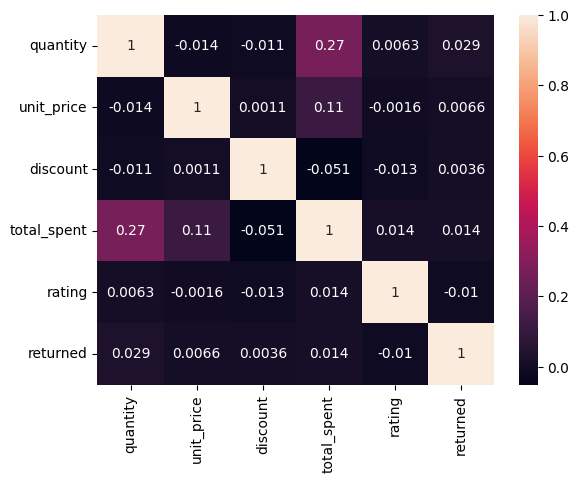

In [86]:
import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True)

In [87]:
outlier_index=detect_outliers(data=df,n=0,features=["rating"])
df.loc[outlier_index]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
154,TXN-107237,CUST-4451,2024-02-17,Clothing,Backpack,5.0,50.59,0.140,217.54,Cash,In-Store,South,Regular,99.00,0.0
1339,TXN-104693,CUST-4671,2022-10-29,Sports & Outdoors,Water Bottle,5.0,24.25,0.110,107.91,Debit Card,Mobile App,Central,Regular,99.00,0.0
2083,TXN-104968,CUST-1563,2024-06-10,Toys & Games,Nerf Blaster,8.0,26.41,0.180,173.25,PayPal,Online,South,ERROR,99.00,0.0
3253,TXN-108876,CUST-3098,2024-11-13,Books,Clean Code,6.0,32.05,0.130,167.30,Debit Card,Online,North,New,7.00,0.0
4214,TXN-102002,CUST-1547,2022-09-20,Toys & Games,Jigsaw Puzzle,1.0,19.10,0.040,18.34,Cash,Online,Central,Regular,99.00,0.0
4487,TXN-104804,CUST-1928,2023-04-06,Books,Statistics 101,9.0,26.37,0.060,223.09,Credit Card,Online,Central,Premium,99.00,0.0
4501,TXN-106481,CUST-3495,2023-02-15,Electronics,Tablet,9.0,304.54,0.240,2083.05,Debit Card,In-Store,East,Regular,99.00,0.0
4657,TXN-108467,CUST-1660,2022-08-21,Electronics,Tablet,9.0,351.82,0.190,2564.77,Bank Transfer,In-Store,West,VIP,7.00,1.0
5150,TXN-106623,CUST-3114,2024-05-09,Beauty & Personal Care,Face Serum,2.0,36.93,0.000,73.86,Bank Transfer,Online,South,Regular,7.00,0.0
5489,TXN-106049,CUST-2644,2022-09-20,Toys & Games,Lego Creator Set,4.0,74.69,0.178,280.83,Bank Transfer,Mobile App,South,New,22.28,1.0


In [88]:
## rating from 0 to 5 but we have some outliers greater than 5 so we will handle them
def handle_outliers_rating(x):
    if x > 5:
        return 5
    else:
        return x
    

In [89]:
df["rating"]=df["rating"].apply(handle_outliers_rating)

In [90]:
px.box(data_frame=df,x="rating")

In [91]:
df[df["quantity"]=="UNKNOWN"]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9214 entries, 0 to 9213
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9214 non-null   str           
 1   customer_id       9214 non-null   str           
 2   transaction_date  9214 non-null   datetime64[us]
 3   category          9214 non-null   str           
 4   item              9214 non-null   str           
 5   quantity          9214 non-null   float64       
 6   unit_price        9214 non-null   float64       
 7   discount          9214 non-null   float64       
 8   total_spent       9214 non-null   float64       
 9   payment_method    9214 non-null   str           
 10  location          9214 non-null   str           
 11  region            9214 non-null   str           
 12  customer_segment  9214 non-null   str           
 13  rating            9214 non-null   float64       
 14  returned          9214 non-null   f

In [93]:
num_cols=df.select_dtypes(include="number").columns

In [94]:
for i in num_cols:
    px.histogram(data_frame=df,x=i).show()
    px.box(data_frame=df,x=i).show()

In [95]:
outlier_index=detect_outliers(data=df,n=0,features=["unit_price"])
df2=df.loc[outlier_index]
df2

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
9,TXN-104058,CUST-1705,2023-12-18,Electronics,Smartphone,4.0,644.53,0.01,2552.34,Bank Transfer,In-Store,South,Premium,2.5,0.0
16,TXN-106120,CUST-4773,2023-05-11,Electronics,Tablet,1.0,345.90,0.02,338.98,Bank Transfer,Online,Central,Regular,3.8,1.0
24,TXN-107116,CUST-4227,2023-01-29,Electronics,Smart Watch,9.0,237.83,0.30,1498.33,Credit Card,Mobile App,South,New,3.8,1.0
52,TXN-102720,CUST-2377,2023-05-31,Home & Kitchen,Vacuum Cleaner,1.0,181.00,0.30,126.70,Debit Card,In-Store,Central,Premium,3.0,0.0
102,TXN-101311,CUST-4582,2022-07-06,Sports & Outdoors,Treadmill,9.0,575.45,0.23,4453.98,Bank Transfer,In-Store,South,Regular,1.9,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9169,TXN-107673,CUST-4740,2022-06-01,Home & Kitchen,Vacuum Cleaner,4.0,194.88,0.17,647.00,Cash,Online,North,Premium,3.8,0.0
9172,TXN-105603,CUST-4163,2024-10-29,Home & Kitchen,Cookware Set,1.0,7589.40,0.25,110.61,Bank Transfer,Online,South,Regular,1.8,0.0
9178,TXN-105215,CUST-4415,2022-08-23,Electronics,Smartphone,5.0,651.97,0.21,2575.28,Bank Transfer,In-Store,North,New,1.2,0.0
9195,TXN-100591,CUST-1223,2022-11-01,Home & Kitchen,Vacuum Cleaner,8.0,214.11,0.02,1678.62,Cash,Online,North,New,2.0,0.0


In [96]:

df2["item"].value_counts()

item
Smart Watch                 122
Treadmill                   121
Tablet                      116
Smartphone                  114
Laptop                      104
Monitor                     103
Vacuum Cleaner              102
Car Phone Mount               6
Clean Code                    3
Dumbbells Set                 3
Jump Starter                  2
The Pragmatic Programmer      2
Python for Data Science       2
Car Vacuum                    2
Bluetooth Speaker             2
Electric Toothbrush           2
Water Bottle                  2
Running Shoes                 2
Seat Covers Set               1
Perfume Set                   1
Lego Creator Set              1
Sneakers                      1
USB Car Charger               1
ERROR                         1
Face Cream                    1
Yoga Pants                    1
Action Figure Set             1
Cycling Helmet                1
UNKNOWN                       1
Cap                           1
Face Serum                    1
Des

In [97]:
## Not logic that car phone mount has unit price of 500 but we have to handle it because it is an outlier and it will affect our model
df[df["item"]=="Car Phone Mount"]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
74,TXN-102608,CUST-1046,2022-06-24,Automotive,Car Phone Mount,2.0,21.96,0.27,32.06,Cash,Mobile App,Central,Regular,3.5,1.0
113,TXN-104955,CUST-1782,2024-03-11,Automotive,Car Phone Mount,6.0,18.67,0.10,100.82,Debit Card,Mobile App,Central,Regular,4.6,0.0
125,TXN-104551,CUST-1732,2022-10-14,Automotive,Car Phone Mount,1.0,20.74,0.01,20.53,Cash,In-Store,East,Premium,1.5,0.0
142,TXN-106899,CUST-1049,2024-12-18,Automotive,Car Phone Mount,5.0,19.42,0.24,73.80,Credit Card,Online,West,Premium,4.5,0.0
224,TXN-106668,CUST-1976,2022-01-06,Automotive,Car Phone Mount,4.0,18.83,0.09,68.54,Credit Card,In-Store,North,VIP,2.4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8852,TXN-105436,CUST-3771,2023-11-06,Automotive,Car Phone Mount,1.0,20.92,0.24,15.90,Credit Card,Mobile App,South,VIP,1.8,0.0
8855,TXN-106974,CUST-4921,2022-03-19,Automotive,Car Phone Mount,10.0,20.95,0.14,180.17,Debit Card,Mobile App,South,Premium,1.4,0.0
8925,TXN-101849,CUST-1706,2023-01-22,Automotive,Car Phone Mount,8.0,21.98,0.19,142.43,Debit Card,Mobile App,South,Regular,4.5,0.0
9079,TXN-109720,CUST-4966,2024-10-11,Automotive,Car Phone Mount,4.0,20.76,0.25,62.28,Cash,In-Store,East,Premium,1.6,0.0


In [98]:
corr=df[num_cols].corr()
corr
px.imshow(corr, text_auto=True)

In [99]:
px.box(data_frame=df,x="unit_price")

In [100]:
df.describe()

,transaction_date,quantity,unit_price,discount,total_spent,rating,returned
count,9214,9214.000000,9214.000000,9214.000000,9214.000000,9214.00000,9214.000000
mean,2023-07-04 19:10:24.354243,5.485457,153.823107,0.150356,395.914590,2.98427,0.200651
min,2022-01-01 00:00:00,1.000000,9.000000,0.000000,-2307.690000,0.00000,0.000000
25%,2022-10-13 00:00:00,3.000000,28.880000,0.080000,92.677500,2.00000,0.000000
50%,2023-07-04 00:00:00,5.000000,45.955000,0.150000,194.515000,3.00000,0.000000
75%,2024-03-28 00:00:00,8.000000,83.705000,0.220000,382.187500,3.90000,0.000000
max,2024-12-30 00:00:00,10.000000,19246.480000,0.300000,9583.020000,5.00000,1.000000
std,NaN,2.898357,952.850703,0.085722,752.383071,1.13712,0.395755


In [101]:
df2.describe()  

,transaction_date,quantity,unit_price,discount,total_spent,rating,returned
count,832,832.000000,832.000000,832.00000,832.000000,832.000000,832.000000
mean,2023-06-29 18:29:25.384615,5.350962,1188.107837,0.15163,1986.669736,2.961995,0.217067
min,2022-01-03 00:00:00,1.000000,180.190000,0.00000,-2307.690000,0.000000,0.000000
25%,2022-09-20 12:00:00,3.000000,266.775000,0.08000,738.280000,2.000000,0.000000
50%,2023-06-22 12:00:00,5.000000,351.480000,0.15000,1538.000000,2.950000,0.000000
75%,2024-04-07 12:00:00,8.000000,713.735000,0.23000,2569.282500,3.900000,0.000000
max,2024-12-30 00:00:00,10.000000,19246.480000,0.30000,9583.020000,5.000000,1.000000
std,NaN,2.835124,2979.652657,0.08702,1738.316435,1.141700,0.406857


## I will handle top 7 outliers and drop the bottom

In [102]:
price_map = {
    'Treadmill': 599.99,
    'Tablet': 329.99,
    'Smart Watch': 249.99,
    'Smartphone': 699.99,
    'Monitor': 299.99,
    'Laptop': 899.99,
    'Vacuum Cleaner': 199.99,
}


expensive_items = list(price_map.keys())

def fix_price(row):
    correct_price = price_map.get(row['item'], None)
    
    if row['unit_price'] > 900:
        
        if row['item'] in expensive_items:
            return correct_price
        else:
            return -1
    
    return row['unit_price']

df['unit_price'] = df.apply(fix_price, axis=1)

# drop flagged rows
df = df[df['unit_price'] != -1].reset_index(drop=True)



In [103]:
def handle_outliers_Neg_total_spent(x):
    if x < 0:
        return x*-1
    else:
        return x

In [104]:
df["total_spent"]=df["total_spent"].apply(handle_outliers_Neg_total_spent)

In [105]:
df["total_spent"]=df["quantity"]*df["unit_price"]*(1-df["discount"])    

In [106]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1.0,23.14,0.250,17.35500,Cash,Online,East,VIP,1.6,0.0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7.0,38.18,0.240,203.11760,Credit Card,Online,South,ERROR,2.5,0.0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2.0,96.92,0.290,137.62640,Cash,Mobile App,South,Premium,5.0,1.0
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5.0,72.73,0.090,330.92150,PayPal,Online,West,VIP,2.0,0.0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9.0,18.38,0.206,131.34348,Cash,Online,North,Regular,1.5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9162,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9.0,20.30,0.210,144.33300,Cash,Mobile App,West,ERROR,4.4,0.0
9163,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4.0,41.03,0.110,146.06680,Credit Card,Mobile App,East,New,5.0,0.0
9164,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2.0,22.31,0.240,33.91120,Cash,Mobile App,South,Premium,2.7,0.0
9165,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3.0,21.45,0.240,48.90600,PayPal,Online,West,New,2.6,0.0


In [107]:
px.box(data_frame=df,x="unit_price")

In [108]:
# Not all outliers are wrong 
df[df["unit_price"]>200]

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
9,TXN-104058,CUST-1705,2023-12-18,Electronics,Smartphone,4.0,644.53,0.01,2552.3388,Bank Transfer,In-Store,South,Premium,2.5,0.0
16,TXN-106120,CUST-4773,2023-05-11,Electronics,Tablet,1.0,345.90,0.02,338.9820,Bank Transfer,Online,Central,Regular,3.8,1.0
24,TXN-107116,CUST-4227,2023-01-29,Electronics,Smart Watch,9.0,237.83,0.30,1498.3290,Credit Card,Mobile App,South,New,3.8,1.0
102,TXN-101311,CUST-4582,2022-07-06,Sports & Outdoors,Treadmill,9.0,575.45,0.23,3987.8685,Bank Transfer,In-Store,South,Regular,1.9,1.0
128,TXN-101907,CUST-1977,2022-03-23,Electronics,Smart Watch,7.0,254.42,0.23,1371.3238,Bank Transfer,Online,Central,New,3.7,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9113,TXN-107963,CUST-1855,2022-11-01,Electronics,Monitor,4.0,298.99,0.06,1124.2024,PayPal,In-Store,South,Premium,2.4,0.0
9120,TXN-104210,CUST-1758,2024-01-29,Electronics,Smartphone,6.0,678.71,0.07,3787.2018,Credit Card,In-Store,East,VIP,5.0,0.0
9131,TXN-105215,CUST-4415,2022-08-23,Electronics,Smartphone,5.0,651.97,0.21,2575.2815,Bank Transfer,In-Store,North,New,1.2,0.0
9148,TXN-100591,CUST-1223,2022-11-01,Home & Kitchen,Vacuum Cleaner,8.0,214.11,0.02,1678.6224,Cash,Online,North,New,2.0,0.0


In [109]:
def handle_outliers_return(x):
    if x > 0.5:
        return 1
    else:
        return 0

In [110]:
df["returned"]=df["returned"].apply(handle_outliers_return)

In [111]:
df.drop(df[df["rating"] < 1].index, inplace=True)

In [112]:
  for i in num_cols:
    px.histogram(data_frame=df,x=i).show()
    px.box(data_frame=df,x=i).show()

## Outliers in columns total spent and unit price is logic due to scalary of things like laptops,smartphones

In [113]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1.0,23.14,0.250,17.35500,Cash,Online,East,VIP,1.6,0
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7.0,38.18,0.240,203.11760,Credit Card,Online,South,ERROR,2.5,0
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2.0,96.92,0.290,137.62640,Cash,Mobile App,South,Premium,5.0,1
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5.0,72.73,0.090,330.92150,PayPal,Online,West,VIP,2.0,0
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9.0,18.38,0.206,131.34348,Cash,Online,North,Regular,1.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9162,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9.0,20.30,0.210,144.33300,Cash,Mobile App,West,ERROR,4.4,0
9163,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4.0,41.03,0.110,146.06680,Credit Card,Mobile App,East,New,5.0,0
9164,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2.0,22.31,0.240,33.91120,Cash,Mobile App,South,Premium,2.7,0
9165,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3.0,21.45,0.240,48.90600,PayPal,Online,West,New,2.6,0


In [114]:
df["year"]=df["transaction_date"].dt.year
df.head()

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned,year
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1.0,23.14,0.250,17.35500,Cash,Online,East,VIP,1.6,0,2022
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7.0,38.18,0.240,203.11760,Credit Card,Online,South,ERROR,2.5,0,2024
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2.0,96.92,0.290,137.62640,Cash,Mobile App,South,Premium,5.0,1,2023
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5.0,72.73,0.090,330.92150,PayPal,Online,West,VIP,2.0,0,2022
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9.0,18.38,0.206,131.34348,Cash,Online,North,Regular,1.5,1,2023


In [115]:
df["month_year"]=df["transaction_date"].dt.to_period("M")

df.head()

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned,year,month_year
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1.0,23.14,0.250,17.35500,Cash,Online,East,VIP,1.6,0,2022,2022-10
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7.0,38.18,0.240,203.11760,Credit Card,Online,South,ERROR,2.5,0,2024,2024-06
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2.0,96.92,0.290,137.62640,Cash,Mobile App,South,Premium,5.0,1,2023,2023-04
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5.0,72.73,0.090,330.92150,PayPal,Online,West,VIP,2.0,0,2022,2022-06
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9.0,18.38,0.206,131.34348,Cash,Online,North,Regular,1.5,1,2023,2023-06


In [116]:
plt_df=df.groupby("month_year")["total_spent"].mean().reset_index()
plt_df

plt_df["month_year"] = plt_df["month_year"].astype(str)
plt_df["total_spent"] = plt_df["total_spent"].astype(float)


In [117]:
px.line(data_frame=plt_df,x="month_year",y="total_spent")

In [118]:
df.head()

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned,year,month_year
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1.0,23.14,0.250,17.35500,Cash,Online,East,VIP,1.6,0,2022,2022-10
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7.0,38.18,0.240,203.11760,Credit Card,Online,South,ERROR,2.5,0,2024,2024-06
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2.0,96.92,0.290,137.62640,Cash,Mobile App,South,Premium,5.0,1,2023,2023-04
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5.0,72.73,0.090,330.92150,PayPal,Online,West,VIP,2.0,0,2022,2022-06
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9.0,18.38,0.206,131.34348,Cash,Online,North,Regular,1.5,1,2023,2023-06


## What are the top 10 best-selling items by total revenue?

In [119]:
pltt2=df.groupby("item")["total_spent"].sum().round(2).reset_index().sort_values("total_spent", ascending=False).head(10)
pltt2

,item,total_spent
42,Laptop,430693.15
62,Smartphone,331005.98
73,Treadmill,305922.44
68,Tablet,184766.58
47,Monitor,148003.33
61,Smart Watch,136236.68
76,Vacuum Cleaner,94554.54
20,Cookware Set,81972.36
80,Wireless Headphones,79754.92
79,Winter Jacket,68694.68


In [120]:
px.bar(data_frame=pltt2,x="item",y="total_spent")

## Which customer segment spends the most on average per transaction?


In [121]:
## Which customer segment spends the most on average per transaction?
segment_df=df.groupby("customer_segment")["total_spent"].mean().reset_index().sort_values("total_spent", ascending=False)
segment_df

px.bar(data_frame=segment_df,x="customer_segment",y="total_spent")

## Deployment

In [122]:
%%writefile my_text.txt 
"HELLO WORLD"

Overwriting my_text.txt


In [123]:
%%writefile app.py
import streamlit as st

# Text option
st.title("Retail Store Sales Analysis")
st.header("Welcome to the Retail Store Sales Analysis App!")
st.write("This app provides insights into retail store sales data, allowing you to explore trends, analyze customer behavior, and make informed business decisions. Use the sidebar to navigate through different sections of the analysis and discover valuable insights about your retail store's performance.")
st.image("imgg.png")

Overwriting app.py


In [124]:
#only run once to create the file
! streamlit run app.py

^C


In [125]:
df

,transaction_id,customer_id,transaction_date,category,item,quantity,unit_price,discount,total_spent,payment_method,location,region,customer_segment,rating,returned,year,month_year
0,TXN-106332,CUST-2428,2022-10-21,Automotive,Steering Wheel Cover,1.0,23.14,0.250,17.35500,Cash,Online,East,VIP,1.6,0,2022,2022-10
1,TXN-105698,CUST-3147,2024-06-16,Automotive,Car Floor Mats,7.0,38.18,0.240,203.11760,Credit Card,Online,South,ERROR,2.5,0,2024,2024-06
2,TXN-100808,CUST-4622,2023-04-20,Automotive,Dash Cam,2.0,96.92,0.290,137.62640,Cash,Mobile App,South,Premium,5.0,1,2023,2023-04
3,TXN-100488,CUST-3616,2022-06-05,Home & Kitchen,Coffee Maker,5.0,72.73,0.090,330.92150,PayPal,Online,West,VIP,2.0,0,2022,2022-06
4,TXN-105353,CUST-1082,2023-06-12,Toys & Games,Jigsaw Puzzle,9.0,18.38,0.206,131.34348,Cash,Online,North,Regular,1.5,1,2023,2023-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9162,TXN-107890,CUST-2134,2022-11-27,Clothing,Cap,9.0,20.30,0.210,144.33300,Cash,Mobile App,West,ERROR,4.4,0,2022,2022-11
9163,TXN-101768,CUST-2690,2022-03-16,Home & Kitchen,Rice Cooker,4.0,41.03,0.110,146.06680,Credit Card,Mobile App,East,New,5.0,0,2022,2022-03
9164,TXN-109929,CUST-3946,2022-10-25,Toys & Games,Play-Doh Kit,2.0,22.31,0.240,33.91120,Cash,Mobile App,South,Premium,2.7,0,2022,2022-10
9165,TXN-103240,CUST-4340,2022-04-24,Sports & Outdoors,Resistance Bands,3.0,21.45,0.240,48.90600,PayPal,Online,West,New,2.6,0,2022,2022-04


In [131]:
# Save full cleaned dataframe
df.to_csv("retail_store_cleaned.csv", index=False)
